# SISO Convolution — Toeplitz + Diagonal (Halevi-Shoup) Metodu / OpenFHE

Bir convolution katmanını Toeplitz matrisine çevirip, diagonal metotla şifreli olarak hesaplıyorum. Önce küçük bir örnek, sonra MNIST üzerinde deniyorum ve sonucu şifresiz NumPy/TensorFlow ile karşılaştırıyorum.

## Kurulum

OpenFHE için Python 3.10 ortamı kurulumu


In [1]:
# ortami kuruyorum (python 3.10 + openfhe)
!pip install -q uv
!uv python install 3.10
!uv venv /content/fhe310 --python 3.10
!uv pip install --python /content/fhe310/bin/python "openfhe==1.5.1.0.22.4" numpy
!/content/fhe310/bin/python -c "import openfhe, sys; print('OpenFHE hazir, Python', sys.version.split()[0])"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 35.9 MB/s eta 0:00:00
Installed Python 3.10.20 in 3.51s
 + cpython-3.10.20-linux-x86_64-gnu (python3.10)
Using CPython 3.10.20
Creating virtual environment at: fhe310
Activate with: source fhe310/bin/activate
Using Python 3.10.20 environment at: fhe310
Resolved 2 packages in 220ms
Prepared 2 packages in 635ms
Installed 2 packages in 31ms
 + numpy==2.2.6
 + openfhe==1.5.1.0.22.4
OpenFHE hazir, Python 3.10.20


## Yöntem

Convolution'ı bir Toeplitz matrisiyle yazıyorum: çıktı = T·x. T dikdörtgen olabildiği için kareye tamamlıyorum, sonra diagonal metotla çarpıyorum. Matris çoğunlukla sıfır olduğundan sadece sıfır olmayan diagonalleri işliyorum; böylece rotation ve çarpım sayısı, sıfır olmayan diagonal sayısına eşit oluyor. Toeplitz'i input boyutu, kernel, stride ve padding'e göre kuruyorum, tek bir örneğe sabit değil.

In [2]:
%%writefile /content/siso_fhe.py
import time
import argparse
import numpy as np
from openfhe import CCParamsCKKSRNS, GenCryptoContext, PKESchemeFeature


def conv2d_ref(x, kernel, stride=1, padding=0):
    hi, wi = x.shape
    fh, fw = kernel.shape
    xp = np.pad(x, ((padding, padding), (padding, padding)), mode="constant")
    hp, wp = xp.shape
    ho = (hp - fh) // stride + 1
    wo = (wp - fw) // stride + 1
    out = np.zeros((ho, wo))
    for oy in range(ho):
        for ox in range(wo):
            region = xp[oy*stride:oy*stride+fh, ox*stride:ox*stride+fw]
            out[oy, ox] = np.sum(region * kernel)
    return out


def build_toeplitz(hi, wi, kernel, stride=1, padding=0):
    fh, fw = kernel.shape
    hp, wp = hi + 2*padding, wi + 2*padding
    ho = (hp - fh) // stride + 1
    wo = (wp - fw) // stride + 1
    T = np.zeros((ho*wo, hi*wi))
    for oy in range(ho):
        for ox in range(wo):
            r = oy*wo + ox
            for ky in range(fh):
                for kx in range(fw):
                    py = oy*stride + ky
                    px = ox*stride + kx
                    iy, ix = py - padding, px - padding
                    if 0 <= iy < hi and 0 <= ix < wi:
                        T[r, iy*wi + ix] += kernel[ky, kx]
    return T, (ho, wo)


def square_embed(T, n):
    S = np.zeros((n, n))
    S[:T.shape[0], :T.shape[1]] = T
    return S


def diagonalize(M):
    n = M.shape[0]
    return {k: np.array([M[i, (i + k) % n] for i in range(n)]) for k in range(n)}


def nonzero_keys(diags, tol=1e-12):
    return sorted(k for k, dk in diags.items() if np.any(np.abs(dk) > tol))


def he_siso_conv(x, kernel, stride=1, padding=0, repeats=1):
    x = np.asarray(x, dtype=float)
    hi, wi = x.shape
    n = hi * wi
    T, (ho, wo) = build_toeplitz(hi, wi, kernel, stride, padding)
    S = square_embed(T, n)
    diags = diagonalize(S)
    nz = nonzero_keys(diags)
    reference = conv2d_ref(x, kernel, stride, padding)

    p = CCParamsCKKSRNS()
    p.SetMultiplicativeDepth(1); p.SetScalingModSize(45); p.SetFirstModSize(60)
    cc = GenCryptoContext(p)
    for f in (PKESchemeFeature.PKE, PKESchemeFeature.LEVELEDSHE, PKESchemeFeature.KEYSWITCH):
        cc.Enable(f)

    ring = cc.GetRingDimension()
    slots = ring // 2
    if n > slots // 2:
        raise ValueError(f"n={n} bu ring icin cok buyuk (slots={slots}).")
    reps = slots // n

    keys = cc.KeyGen()
    cc.EvalMultKeyGen(keys.secretKey)
    rot_ks = [k for k in nz if k != 0]
    if rot_ks:
        cc.EvalRotateKeyGen(keys.secretKey, rot_ks)

    tile = lambda a: np.tile(a, reps).tolist()
    ctv = cc.Encrypt(keys.publicKey, cc.MakeCKKSPackedPlaintext(tile(x.flatten())))
    dpts = {k: cc.MakeCKKSPackedPlaintext(tile(diags[k])) for k in nz}

    times = []
    acc = None
    for _rep in range(max(1, repeats)):
        ops = {"rot": 0, "pmult": 0, "add": 0}
        t0 = time.perf_counter()
        acc = None
        for k in nz:
            cr = cc.EvalRotate(ctv, k) if k else ctv
            if k:
                ops["rot"] += 1
            part = cc.EvalMult(cr, dpts[k]); ops["pmult"] += 1
            if acc is None:
                acc = part
            else:
                acc = cc.EvalAdd(acc, part); ops["add"] += 1
        times.append(time.perf_counter() - t0)
    dt_mean = float(np.mean(times)); dt_std = float(np.std(times))

    dec = cc.Decrypt(keys.secretKey, acc)
    dec.SetLength(ho * wo)
    he_out = np.array(dec.GetRealPackedValue())[:ho*wo].reshape(ho, wo)

    err = float(np.abs(he_out - reference).mean())
    prec = -np.log2(err) if err > 0 else float("inf")
    return {
        "reference": reference, "he_out": he_out,
        "in_shape": (hi, wi), "out_shape": (ho, wo), "n": n, "ring": ring,
        "nonzero_diag": len(nz), "naive_rot": n, "ops": ops,
        "time_mean": dt_mean, "time_std": dt_std, "repeats": max(1, repeats),
        "match": bool(np.allclose(he_out, reference, atol=1e-3)),
        "err": err, "prec": prec,
    }


def report(title, x, kernel, stride, padding, show_arrays=False, repeats=5):
    r = he_siso_conv(x, kernel, stride, padding, repeats=repeats)
    o = r["ops"]
    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"input={r['in_shape']} kernel={kernel.shape} stride={stride} padding={padding} -> output={r['out_shape']}")
    print(f"n={r['n']} | ring={r['ring']}")
    if show_arrays:
        print("\nNumPy conv:\n", np.round(r["reference"], 4))
        print("\nOpenFHE conv:\n", np.round(r["he_out"], 4))
    print(f"\neslesme: {r['match']} | ort.hata {r['err']:.2e} (~{r['prec']:.1f} bit)")
    print(f"non-zero diagonal: {r['nonzero_diag']} (naif: {r['naive_rot']} -> {r['naive_rot']/max(1,r['nonzero_diag']):.0f}x)")
    print(f"rotation: {o['rot']} | plaintext-carpim: {o['pmult']} | toplama: {o['add']} | derinlik: 1")
    print(f"sure: {r['time_mean']:.4f} +/- {r['time_std']:.4f} s ({r['repeats']} calistirma)")
    print("=" * 60 + "\n")
    return r


def run_small():
    x = np.array([[1, 2, 3, 4],
                  [5, 6, 7, 8],
                  [9, 10, 11, 12],
                  [13, 14, 15, 16]], dtype=float)
    kernel = np.array([[1, 0, -1],
                       [1, 0, -1],
                       [1, 0, -1]], dtype=float)
    report("4x4 same conv (s=1, p=1)", x, kernel, stride=1, padding=1, show_arrays=True)


def _load_mnist_digit():
    import os
    if os.path.exists("/content/mnist_sample.npy"):
        img = np.load("/content/mnist_sample.npy").astype(float)
        src = "gercek MNIST"
    else:
        yy, xx = np.mgrid[0:28, 0:28]
        img = (128 + 100*np.sin(xx/3.0) * np.cos(yy/4.0)).clip(0, 255)
        src = "sentetik 28x28"
    return img / 255.0, src


def run_mnist():
    img, src = _load_mnist_digit()
    kernel = np.array([[1, 2, 1],
                       [2, 4, 2],
                       [1, 2, 1]], dtype=float) / 16.0
    print(f"[girdi: {src}]\n")
    r = report("MNIST 28x28 same conv (s=1, p=1), Gaussian blur",
               img, kernel, stride=1, padding=1, show_arrays=False)
    ho, wo = r["out_shape"]
    cy, cx = ho // 2 - 2, wo // 2 - 2
    ref_c = r["reference"][cy:cy+4, cx:cx+4]
    he_c = r["he_out"][cy:cy+4, cx:cx+4]
    print("NumPy conv [merkez]:\n", np.round(ref_c, 4))
    print("OpenFHE conv [merkez]:\n", np.round(he_c, 4))
    print(f"merkez max |fark| = {np.abs(ref_c - he_c).max():.2e}")
    np.save("/content/mnist_input.npy", img)
    np.save("/content/mnist_kernel.npy", kernel)
    np.save("/content/mnist_ref.npy", r["reference"])
    np.save("/content/mnist_he.npy", r["he_out"])
    print()


def run_table():
    rng = np.random.default_rng(7)
    x = rng.integers(0, 9, size=(8, 8)).astype(float)
    k3 = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float)
    k2 = np.array([[1, 1], [1, 1]], dtype=float)
    cases = [
        ("8x8 same (3x3,s1,p1)", x, k3, 1, 1),
        ("8x8 valid (3x3,s1,p0)", x, k3, 1, 0),
        ("8x8 strided (3x3,s2,p1)", x, k3, 2, 1),
        ("8x8 strided (3x3,s3,p1)", x, k3, 3, 1),
        ("8x8 pool (2x2,s2,p0)", x, k2, 2, 0),
    ]
    print(f"{'konfig':26s} {'cikti':>7} {'nz_diag':>8} {'rot':>5} {'pmult':>6} {'sure(s)':>9} {'ok':>6}")
    print("-" * 74)
    for name, xx, ker, s, p in cases:
        r = he_siso_conv(xx, ker, s, p, repeats=3)
        o = r["ops"]
        print(f"{name:26s} {str(r['out_shape']):>7} {r['nonzero_diag']:>8} "
              f"{o['rot']:>5} {o['pmult']:>6} {r['time_mean']:>9.4f} {str(r['match']):>6}")
    print()


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--mode", choices=["small", "mnist", "table"], default="small")
    args = ap.parse_args()
    {"small": run_small, "mnist": run_mnist, "table": run_table}[args.mode]()


Writing /content/siso_fhe.py


## Küçük örnek

Önce 4×4'lük küçük bir örnek. Kernel basit bir dikey kenar filtresi. Şifreli çıktıyı şifresiz NumPy sonucuyla birebir karşılaştırma.

In [3]:
# kucuk ornegi calistiriyorum
!/content/fhe310/bin/python /content/siso_fhe.py --mode small

4x4 same conv (s=1, p=1)
input=(4, 4) kernel=(3, 3) stride=1 padding=1 -> output=(4, 4)
n=16 | ring=16384

NumPy conv:
 [[ -8.  -4.  -4.  10.]
 [-18.  -6.  -6.  21.]
 [-30.  -6.  -6.  33.]
 [-24.  -4.  -4.  26.]]

OpenFHE conv:
 [[ -8.  -4.  -4.  10.]
 [-18.  -6.  -6.  21.]
 [-30.  -6.  -6.  33.]
 [-24.  -4.  -4.  26.]]

eslesme: True | ort.hata 1.30e-10 (~32.8 bit)
non-zero diagonal: 6 (naif: 16 -> 3x)
rotation: 6 | plaintext-carpim: 6 | toplama: 5 | derinlik: 1
sure: 0.1263 +/- 0.0010 s (5 calistirma)



## MNIST

Şimdi 28×28 gerçek bir MNIST rakamı, kernel 3×3 Gaussian blur. Matris büyük olduğu için sadece ortadan küçük bir dilim yazdırıyorum; tam kontrolü `allclose` ile yapıyorum.  

In [4]:
# gercek mnist rakamini indirip kaydediyorum, bulamazsa alttaki sentetik uretiyor
try:
    import numpy as np
    from tensorflow.keras.datasets import mnist
    (x_train, _), _ = mnist.load_data()
    np.save("/content/mnist_sample.npy", x_train[7])
    print("mnist kaydedildi:", x_train[7].shape)
except Exception as e:
    print("mnist yuklenemedi, sentetik kullanilacak:", e)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mnist kaydedildi: (28, 28)


In [5]:
# mnist testini calistiriyorum
!/content/fhe310/bin/python /content/siso_fhe.py --mode mnist

[girdi: gercek MNIST]

MNIST 28x28 same conv (s=1, p=1), Gaussian blur
input=(28, 28) kernel=(3, 3) stride=1 padding=1 -> output=(28, 28)
n=784 | ring=16384

eslesme: True | ort.hata 5.45e-11 (~34.1 bit)
non-zero diagonal: 9 (naif: 784 -> 87x)
rotation: 8 | plaintext-carpim: 9 | toplama: 8 | derinlik: 1
sure: 1.1435 +/- 0.3761 s (5 calistirma)

NumPy conv [merkez]:
 [[0.1892 0.2485 0.4262 0.6424]
 [0.6255 0.6775 0.8103 0.9287]
 [0.9314 0.9471 0.9772 0.9904]
 [0.7882 0.7875 0.7887 0.8118]]
OpenFHE conv [merkez]:
 [[0.1892 0.2485 0.4262 0.6424]
 [0.6255 0.6775 0.8103 0.9287]
 [0.9314 0.9471 0.9772 0.9904]
 [0.7882 0.7875 0.7887 0.8118]]
merkez max |fark| = 1.27e-10



### TensorFlow kontrolü

Aynı işlemi `tf.nn.conv2d` ile de yapıp NumPy ve şifreli sonuçla aynı çıkıyor mu diye bakıyorum.

In [6]:
# ayni conv'u tensorflow ile de yapip numpy ve sifreli sonucla ayni mi diye bakiyorum
import numpy as np
try:
    import tensorflow as tf
    img = np.load("/content/mnist_input.npy")
    ker = np.load("/content/mnist_kernel.npy")
    ref = np.load("/content/mnist_ref.npy")
    he  = np.load("/content/mnist_he.npy")
    x_t = tf.constant(img.reshape(1, 28, 28, 1), dtype=tf.float64)
    x_t = tf.pad(x_t, [[0, 0], [1, 1], [1, 1], [0, 0]])
    k_t = tf.constant(ker.reshape(3, 3, 1, 1), dtype=tf.float64)
    tf_out = tf.nn.conv2d(x_t, k_t, strides=1, padding="VALID").numpy().reshape(28, 28)
    print("TF == NumPy   :", np.allclose(tf_out, ref, atol=1e-6), "| max fark", f"{np.abs(tf_out - ref).max():.2e}")
    print("TF == sifreli :", np.allclose(tf_out, he, atol=1e-3), "| max fark", f"{np.abs(tf_out - he).max():.2e}")
except Exception as e:
    print("tf karsilastirmasi atlandi:", e)

TF == NumPy   : True | max fark 1.11e-16
TF == sifreli : True | max fark 2.45e-10


### Görsel

Girdi, iki sonuç ve farkı yan yana çiziyorum. Fark haritası neredeyse sıfır olmalı.

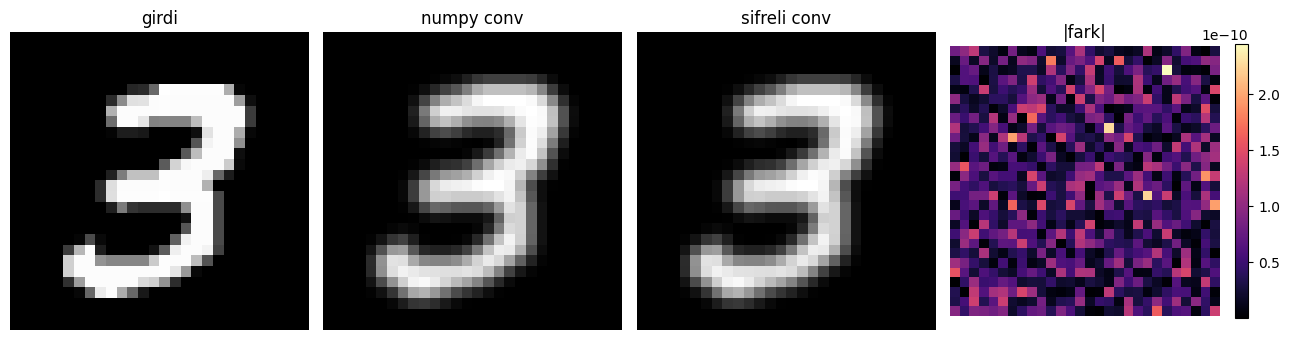

max |fark| = 2.4464401596748005e-10


In [7]:
# girdi, iki sonuc ve farki yan yana ciziyorum
import numpy as np
import matplotlib.pyplot as plt
img = np.load("/content/mnist_input.npy")
ref = np.load("/content/mnist_ref.npy")
he  = np.load("/content/mnist_he.npy")
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("girdi")
ax[1].imshow(ref, cmap="gray"); ax[1].set_title("numpy conv")
ax[2].imshow(he,  cmap="gray"); ax[2].set_title("sifreli conv")
im = ax[3].imshow(np.abs(ref - he), cmap="magma"); ax[3].set_title("|fark|")
fig.colorbar(im, ax=ax[3], fraction=0.046)
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()
print("max |fark| =", float(np.abs(ref - he).max()))

## Farklı parametreler

Aynı kodu farklı stride ve padding ile deniyorum. Stride arttıkça sıfır olmayan diagonal sayısı da artıyor.

In [8]:
# farkli stride/padding deniyorum
!/content/fhe310/bin/python /content/siso_fhe.py --mode table

konfig                       cikti  nz_diag   rot  pmult   sure(s)     ok
--------------------------------------------------------------------------
8x8 same (3x3,s1,p1)        (8, 8)        6     6      6    0.4008   True
8x8 valid (3x3,s1,p0)       (6, 6)       15    14     15    0.9055   True
8x8 strided (3x3,s2,p1)     (4, 4)       46    45     46    1.4264   True
8x8 strided (3x3,s3,p1)     (3, 3)       24    24     24    0.5106   True
8x8 pool (2x2,s2,p0)        (4, 4)       37    36     37    0.7849   True



## Parametre notu

CKKS ayarları: tek bir çarpım yaptığım için multiplicative depth = 1. Ölçek (ScalingModSize) 45, bu da yaklaşık 30+ bit hassasiyet veriyor. Ring boyutunu OpenFHE 128-bit güvenlik için kendisi seçiyor (16384).


## Özet

Şifreli çıktı bütün durumlarda şifresiz sonuçla eşleşti. Same conv'da sıfır olmayan diagonal sayısı görüntü boyutundan bağımsız ve küçük; strided'de artıyor.
